# Подготовка

## Импорты

In [1]:
import numpy as np
import pandas as pd
import random
import copy
from sklearn.model_selection import train_test_split
import pandas as pd
import graphviz

from sklearn.datasets import load_iris

import time

## Классы узлов дерева

In [2]:
class SplitNode:
    """Разделяющий признак"""
    def __init__(self, feature_idx, threshold, left, right):
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.left = left
        self.right = right

class LeafNode:
    """Лист"""
    def __init__(self, class_label):
        self.class_label = class_label


## Функции деревьев решений

In [3]:
def generate_random_tree(max_depth, X, y, current_depth=0):
    """Генерация случайного дерева"""
    
    # Проверка на максимальную глубину и размер подвыборки на узле
    if current_depth == max_depth or len(y) == 0:
        return LeafNode(get_majority_class(y))
    
    # Выбирается случайный признак для разделения (пока только нумерикал)
    feature_idx = np.random.randint(0, X.shape[1])
    feature_values = X[:, feature_idx]
    min_val, max_val = np.min(feature_values), np.max(feature_values)
    
    if min_val == max_val:
        threshold = min_val
    else:
        threshold = np.random.uniform(min_val, max_val)
        
    # Разделение выборки по условию
    left_mask = feature_values <= threshold
    right_mask = ~left_mask
    
    X_left, y_left = X[left_mask], y[left_mask]
    X_right, y_right = X[right_mask], y[right_mask]
    
    # Превращаем в лист, если вся выборка уходит в одну сторону
    if len(y_left) == 0 or len(y_right) == 0:
        return LeafNode(get_majority_class(y))
        
    # Рекурсивная генераци
    left_subtree = generate_random_tree(max_depth, X_left, y_left, current_depth + 1)
    right_subtree = generate_random_tree(max_depth, X_right, y_right, current_depth + 1)
    
    return prune_tree(SplitNode(feature_idx, threshold, left_subtree, right_subtree))

def predict_single(tree, x):
    """Предсказание класса объекта"""
    if isinstance(tree, LeafNode):
        return tree.class_label
    
    if x[tree.feature_idx] <= tree.threshold:
        return predict_single(tree.left, x)
    else:
        return predict_single(tree.right, x)

def evaluate_fitness(tree, X, y):
    """Фитнес-функция дерева"""
    #todo - разные фитнес функции
    predictions = np.array([predict_single(tree, x) for x in X])
    
    return np.mean(predictions == y)

def prune_tree(tree):
    """
    Урезание ветвей, делящихся на листья с одинаковыми классами
    """
    if isinstance(tree, LeafNode):
        return tree
    
    tree.left = prune_tree(tree.left)
    tree.right = prune_tree(tree.right)
        
    if isinstance(tree.left, LeafNode) and isinstance(tree.right, LeafNode):
        if tree.left.class_label == tree.right.class_label:
            return LeafNode(tree.left.class_label)
            
    return tree

def get_majority_class(y):
    """Получает наибольший класс в данном множестве"""
    if len(y) == 0:
        print('WARNING: ноль объектов в подмножестве листа')
        return 0 
    classes, counts = np.unique(y, return_counts=True)
    return classes[np.argmax(counts)]

def get_data_at_node(tree, X, y, path):
    """Возвращает подмножество, получаемое из множества, при проходе по дереву в указанный узел"""
    X_subset, y_subset = X.copy(), y.copy()
    current_node = tree
    for direction in path:
        if direction == 'left':
            mask = X_subset[:, current_node.feature_idx] <= current_node.threshold
        else:
            mask = X_subset[:, current_node.feature_idx] > current_node.threshold
            
        X_subset = X_subset[mask]
        y_subset = y_subset[mask]
        
        current_node = current_node.left if direction == 'left' else current_node.right
        
    return X_subset, y_subset

## Генетическое программирование

### Функции

In [4]:
def get_nodes_and_paths(tree, path=None):
    """Вывод структуры дерева с узлами и путями к ним"""
    if path is None:
        path = []
    nodes = [(tree, path)]
    if isinstance(tree, SplitNode):
        nodes.extend(get_nodes_and_paths(tree.left, path + ['left']))
        nodes.extend(get_nodes_and_paths(tree.right, path + ['right']))
    return nodes

def set_by_path(tree, path, new_node):
    """Замена узла по пути"""
    if not path:
        return new_node  # Замена корня
    curr = tree
    
    for p in path[:-1]:
        curr = getattr(curr, p) #проход по дереву до "родителя" нужного поддерева
    setattr(curr, path[-1], new_node) # замена нужного поддерева
    return tree

def get_max_depth_of_node(node):
    """Вывод максимальной возможной глубины поддерева"""
    if isinstance(node, LeafNode):
        return 0
    return 1 + max(get_max_depth_of_node(node.left), get_max_depth_of_node(node.right))

def tournament_selection(population, fitnesses, k=3):
    """Турнирная селекция"""
    indices = np.random.choice(len(population), k, replace=False)
    best_idx = indices[np.argmax([fitnesses[i] for i in indices])]
    return copy.deepcopy(population[best_idx])

def crossover(p1, p2, max_depth=4):
    """Скрещивание"""
    nodes1 = get_nodes_and_paths(p1)
    nodes2 = get_nodes_and_paths(p2)
    
    # Поиск такой замены, которая не превысит установленную максимальную глубину
    for _ in range(10):
        node1, path1 = random.choice(nodes1)
        node2, path2 = random.choice(nodes2)
        
        depth1 = len(path1)
        max_depth2 = get_max_depth_of_node(node2)
        
        if depth1 + max_depth2 <= max_depth:
            child1 = copy.deepcopy(p1)
            child1 = set_by_path(child1, path1, copy.deepcopy(node2))
            
            return prune_tree(child1)
            
    # Если такой замены нет - возвращается копия первого родителя
    return prune_tree(copy.deepcopy(p1))

def mutate(tree, X, y, max_depth=4, mutation_rate=0.2):
    """Мутация"""
    if random.random() > mutation_rate:
        return copy.deepcopy(tree)
    
    nodes = get_nodes_and_paths(tree)
    node, path = random.choice(nodes)
    current_depth = len(path)
    
    # Использует подмножество, которое "доходит" до этого этапа
    X_subset, y_subset = get_data_at_node(tree, X, y, path)
    
    new_subtree = generate_random_tree(max_depth, X_subset, y_subset, current_depth=current_depth)
    
    child = copy.deepcopy(tree)
    child = set_by_path(child, path, new_subtree)
    
    return prune_tree(child)



### Сам цикл

In [5]:
def gp_decision_tree_classifier(X, y, pop_size=100, generations=10, max_depth=4):
    """
    Генерация дерева алгоритмом генетического программирования
    """
    
    X_vals = X.values if isinstance(X, pd.DataFrame) else np.array(X)
    y_vals = y.values if isinstance(y, pd.Series) else np.array(y)
    
    print("Инициализация начальной популяции...")
    population = [generate_random_tree(max_depth, X_vals, y_vals, current_depth=0) 
                  for _ in range(pop_size)]
    
    
    for gen in range(generations):
        # Оценка пригодности популяции
        fitnesses = [evaluate_fitness(ind, X_vals, y_vals) for ind in population]
        best_fit = max(fitnesses)
        print(f"Популяция {gen + 1}/{generations} - Лучшая точность: {best_fit:.4f}")
        
        new_population = []
        
        # Элитизм
        best_idx = np.argmax(fitnesses)
        new_population.append(copy.deepcopy(population[best_idx]))
        
        # Генерация новой популяции
        while len(new_population) < pop_size:
            # Селекция
            parent1 = tournament_selection(population, fitnesses, k=3)
            parent2 = tournament_selection(population, fitnesses,3)
            
            # Скрещивание и мутация
            child = crossover(parent1, parent2, max_depth=max_depth)
            child = mutate(child, X_vals, y_vals, max_depth=max_depth, mutation_rate=0.2)
            
            new_population.append(child)
            
        population = new_population
     

    final_fitnesses = [evaluate_fitness(ind, X_vals, y_vals) for ind in population]
    best_idx = np.argmax(final_fitnesses)
    best_tree = population[best_idx]
    best_accuracy = final_fitnesses[best_idx]
    
    return best_tree, best_accuracy

## Вывод диаграммы дерева

In [12]:
def print_tree(tree, feature_names=None, class_names=None):
    """Построение диаграммы дерева решений"""

    print("Классы:")
    for class_id, class_name in enumerate(class_names):
        print(f"{class_id} - '{class_name}'")
    print("-" * 30)

    dot = graphviz.Digraph(comment='Decision Tree')
    dot.attr(rankdir='TB', size='10,10') 
    node_id = 0
    
    def add_nodes(node, parent_id=None, edge_label=None):
        nonlocal node_id
        current_id = str(node_id)
        node_id += 1
        
        if isinstance(node, LeafNode):
            label = f"Class: {node.class_label}"
            dot.node(current_id, label, shape='box', style='filled', fillcolor='lightgreen', fontname='Helvetica')
        else:
            f_name = feature_names[node.feature_idx] if feature_names else f"Feature {node.feature_idx}"
            label = f"{f_name} <= {node.threshold:.2f}"
            dot.node(current_id, label, shape='ellipse', style='filled', fillcolor='lightblue', fontname='Helvetica')
            
            add_nodes(node.left, current_id, "True (<=)")
            add_nodes(node.right, current_id, "False (>)")
        
        if parent_id is not None:
            dot.edge(parent_id, current_id, label=edge_label, fontname='Helvetica', fontsize='10')
            
    add_nodes(tree)
    
    dot.render('decision_tree', format='png', cleanup=True)
    #print("Tree saved as 'decision_tree.png'")
    return dot


# Машинное обучение

## Параметры

In [15]:
pop_size = 200
gens = 5
max_depth = 4

In [8]:

# Load the dataset
iris = load_iris()

# Convert to pandas DataFrame and Series (as expected by the GP script)
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = pd.Series(iris.target)


Инициализация начальной популяции...
Популяция 1/5 - Лучшая точность: 0.9667
Популяция 2/5 - Лучшая точность: 0.9667
Популяция 3/5 - Лучшая точность: 0.9750
Популяция 4/5 - Лучшая точность: 0.9750
Популяция 5/5 - Лучшая точность: 0.9750

--- Алгоритм завершен ---
Точность модели: 0.9750
Точность по тестовой выборке:     0.9667

Классы:
0 - 'setosa'
1 - 'versicolor'
2 - 'virginica'
------------------------------


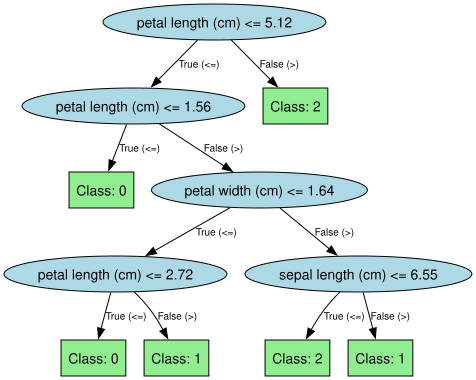

In [17]:
start_time = time.time()

# ==========================================
# 6. Usage Example
# ==========================================

# Split for demonstration (though GP evaluates on the provided X, y)
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

# print("Starting Genetic Programming Decision Tree Classifier...")
# print("Constraints: Pop=100, Gen=10, Max Depth=4 (5 levels: 4 splits, 1 leaf)")

# Run the GP algorithm
best_model, best_acc = gp_decision_tree_classifier(
    X=X_train, 
    y=y_train, 
    pop_size=pop_size, 
    generations=gens, 
    max_depth=max_depth  
)

print("\n--- Алгоритм завершен ---")
print(f"Точность модели: {best_acc:.4f}")

# Evaluate on test set to show generalization
test_acc = evaluate_fitness(best_model, X_test.values, y_test.values)
print(f"Точность по тестовой выборке:     {test_acc:.4f}\n")

print_tree(best_model, feature_names=iris.feature_names, class_names=iris.target_names)



--- Scikit-Learn CART Decision Tree Results ---
Training Accuracy: 0.9750
Testing Accuracy:  1.0000

Tree Structure (Text):
|--- petal length (cm) <= 2.45
|   |--- class: 0
|--- petal length (cm) >  2.45
|   |--- petal length (cm) <= 4.75
|   |   |--- petal width (cm) <= 1.65
|   |   |   |--- class: 1
|   |   |--- petal width (cm) >  1.65
|   |   |   |--- class: 2
|   |--- petal length (cm) >  4.75
|   |   |--- petal width (cm) <= 1.75
|   |   |   |--- petal length (cm) <= 4.95
|   |   |   |   |--- class: 1
|   |   |   |--- petal length (cm) >  4.95
|   |   |   |   |--- class: 2
|   |   |--- petal width (cm) >  1.75
|   |   |   |--- petal length (cm) <= 4.85
|   |   |   |   |--- class: 2
|   |   |   |--- petal length (cm) >  4.85
|   |   |   |   |--- class: 2



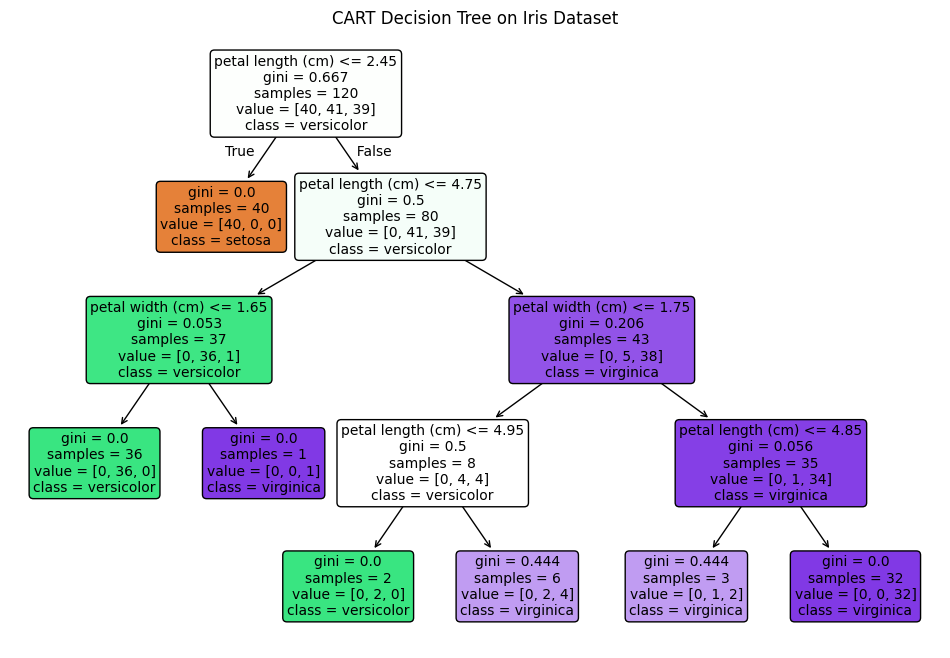

In [10]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import accuracy_score

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# 2. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize the CART Decision Tree Classifier
# We set max_depth=4 to keep it comparable to your GP experiment, 
# but you can remove it to let the tree grow fully.
cart_model = DecisionTreeClassifier(max_depth=4, random_state=42, criterion='gini')

# 4. Fit the model to the training data
cart_model.fit(X_train, y_train)

# 5. Make predictions and evaluate
y_pred = cart_model.predict(X_test)
train_acc = accuracy_score(y_train, cart_model.predict(X_train))
test_acc = accuracy_score(y_test, y_pred)

print("--- Scikit-Learn CART Decision Tree Results ---")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}\n")

# 6. Print the tree structure as text (similar to your GP print_tree function)
print("Tree Structure (Text):")
tree_text = export_text(cart_model, feature_names=feature_names)
print(tree_text)

# 7. (Optional) Plot the tree graphically
plt.figure(figsize=(12, 8))
plot_tree(cart_model, 
          feature_names=feature_names, 
          class_names=class_names, 
          filled=True, 
          rounded=True, 
          fontsize=10)
plt.title("CART Decision Tree on Iris Dataset")
plt.show()

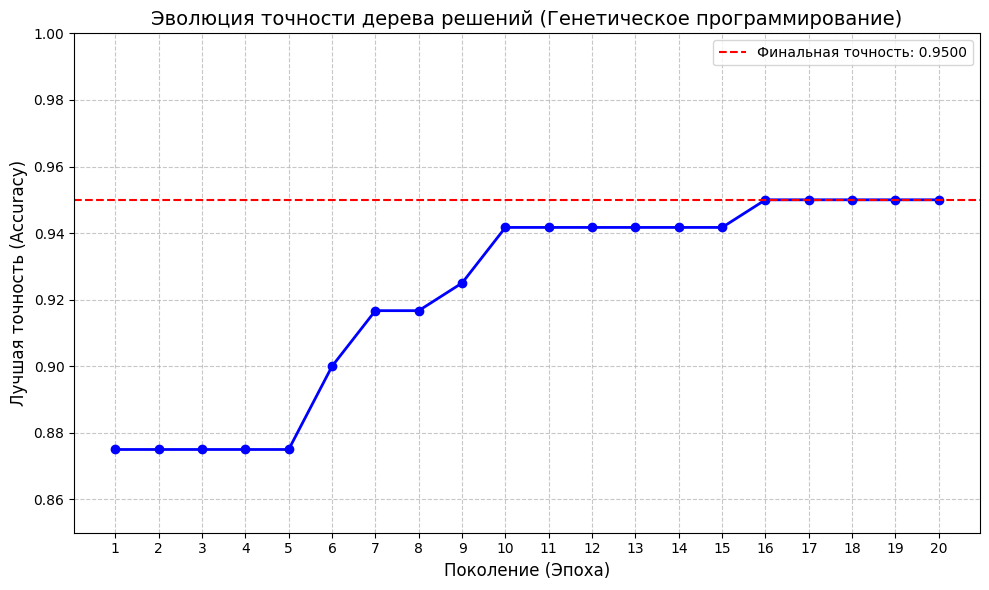

In [11]:
import matplotlib.pyplot as plt

# Значения точности, сохраненные в выводе ячейки (из 20 поколений)
accuracy_history = [
    0.8750,  # Generation 1
    0.8750,  # Generation 2
    0.8750,  # Generation 3
    0.8750,  # Generation 4
    0.8750,  # Generation 5
    0.9000,  # Generation 6
    0.9167,  # Generation 7
    0.9167,  # Generation 8
    0.9250,  # Generation 9
    0.9417,  # Generation 10
    0.9417,  # Generation 11
    0.9417,  # Generation 12
    0.9417,  # Generation 13
    0.9417,  # Generation 14
    0.9417,  # Generation 15
    0.9500,  # Generation 16
    0.9500,  # Generation 17
    0.9500,  # Generation 18
    0.9500,  # Generation 19
    0.9500,  # Generation 20
]

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(accuracy_history) + 1), accuracy_history, 
         marker='o', linestyle='-', color='b', linewidth=2, markersize=6)

# Настройка осей и заголовка
plt.title('Эволюция точности дерева решений (Генетическое программирование)', fontsize=14)
plt.xlabel('Поколение (Эпоха)', fontsize=12)
plt.ylabel('Лучшая точность (Accuracy)', fontsize=12)
plt.xticks(range(1, len(accuracy_history) + 1))
plt.ylim(0.85, 1.0)  # Уменьшаем диапазон по Y для лучшей визуализации изменений
plt.grid(True, linestyle='--', alpha=0.7)

# Добавляем горизонтальную линию для финальной точности
plt.axhline(y=accuracy_history[-1], color='r', linestyle='--', 
            label=f'Финальная точность: {accuracy_history[-1]:.4f}')
plt.legend()

plt.tight_layout()
plt.show()